# Extra: Threshold tuning Patterns 2 and 3

In [ ]:
# https://pandas.pydata.org/docs/
import pandas as pd

# https://numpy.org/doc/
import numpy as np

# https://seaborn.pydata.org/
import seaborn as sns

# https://matplotlib.org/
import matplotlib.pyplot as plt

# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html
from sklearn.datasets import fetch_openml

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
from sklearn.model_selection import train_test_split

# https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
from sklearn.linear_model import LogisticRegression

# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
from sklearn.ensemble import RandomForestClassifier

# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.label_binarize.html
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
from sklearn.preprocessing import StandardScaler, label_binarize, OneHotEncoder

# https://scikit-learn.org/stable/modules/generated/sklearn.compose.make_column_transformer.html
from sklearn.compose import make_column_transformer

# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html
from sklearn.pipeline import make_pipeline

# https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)

## Pattern 2 — Minimize false positives (precision-first)

**Application:** object recognition, OCR, search-result ranking, grammar suggestions.

- A **false positive** means acting when you should not have — misclassifying a van as a bus. The system loses trust.
- **Advice from the lesson:** fix precision high (e.g. $\geq 95\%$), then recover as much recall as possible.

**Dataset:** [Vehicle silhouettes](https://www.openml.org/d/54) from OpenML — 18 numeric shape measurements, **four vehicle types** (`bus`, `opel`, `saab`, `van`). Macro accuracy is only $\approx 77\%$ with a random forest, so the reject option has room to show a real precision–recall trade-off.

### Load four vehicle classes and split

In [ ]:
vehicle = fetch_openml("vehicle", version=1, as_frame=True)
X_vehicle = vehicle.data
y_vehicle = vehicle.target.astype(str)  # bus, opel, saab, van

classes_v = sorted(y_vehicle.unique())

print(f"Samples: {X_vehicle.shape[0]:,}")
print(f"Classes: {classes_v}")

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vehicle,
    y_vehicle,
    test_size=0.25,
    random_state=42,
    stratify=y_vehicle,  # keep every vehicle type equally represented in train and test
)

Samples: 846
Classes: ['bus', 'opel', 'saab', 'van']


### Mechanics primer: probabilities and the reject option

A multiclass classifier outputs one probability **per class**; `predict` returns the **argmax**.

- The **confidence** of a prediction is the largest of those probabilities.
- The **reject option** keeps the prediction only when confidence $\geq$ a threshold; otherwise the model abstains.
- Abstaining on shaky cases **raises precision** on the predictions we do make, at the cost of **recall** (the abstained cases become misses).

### Compare models with summary metrics

For multiclass we average the binary summary metrics over classes (**one-vs-rest, macro**).

In [ ]:
log_reg_vehicle = make_pipeline(
    StandardScaler(),  # scale shape features so logistic regression converges
    LogisticRegression(max_iter=1000, random_state=42),
)
rf_vehicle = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

candidates_vehicle = {
    "LogisticRegression": log_reg_vehicle,
    "RandomForest": rf_vehicle,
}

# One-hot form of the labels, needed for the macro-averaged AUPRC
y_test_bin_v = label_binarize(y_test_v, classes=classes_v)

summary_vehicle = []
for name, model in candidates_vehicle.items():
    model.fit(X_train_v, y_train_v)
    proba = model.predict_proba(X_test_v)  # shape (n_samples, 4)
    summary_vehicle.append(
        {
            "model": name,
            "AUROC (macro OvR)": roc_auc_score(
                y_test_v,
                proba,
                multi_class="ovr",  # one-vs-rest for multiclass
                average="macro",  # unweighted mean over the four classes
            ),
            "AUPRC (macro)": average_precision_score(
                y_test_bin_v,
                proba,
                average="macro",
            ),
        }
    )

summary_vehicle_df = pd.DataFrame(summary_vehicle).set_index("model")
summary_vehicle_df

,AUROC (macro OvR),AUPRC (macro)
model,,
LogisticRegression,0.957185,0.884337
RandomForest,0.937005,0.840681


In [ ]:
best_name_vehicle = summary_vehicle_df["AUPRC (macro)"].idxmax()
best_model_vehicle = candidates_vehicle[best_name_vehicle]

print(f"Selected model: {best_name_vehicle}")

Selected model: LogisticRegression


### Precision and recall *before* tuning

With no reject option (every sample gets a prediction), `classification_report` shows per-class precision and recall plus the **macro average** — already well below 1.

In [ ]:
y_pred_default_v = best_model_vehicle.predict(X_test_v)

macro_precision_before_v = precision_score(
    y_test_v, y_pred_default_v, labels=classes_v, average="macro"
)
macro_recall_before_v = recall_score(
    y_test_v, y_pred_default_v, labels=classes_v, average="macro"
)

print("Before tuning (no abstention, coverage = 100%):")
print(f"  Macro precision: {macro_precision_before_v:.3f}")
print(f"  Macro recall:    {macro_recall_before_v:.3f}\n")
print(classification_report(y_test_v, y_pred_default_v, digits=3))

Before tuning (no abstention, coverage = 100%):
  Macro precision: 0.825
  Macro recall:    0.826

              precision    recall  f1-score   support

         bus      0.945     0.945     0.945        55
        opel      0.702     0.623     0.660        53
        saab      0.712     0.778     0.743        54
         van      0.941     0.960     0.950        50

    accuracy                          0.825       212
   macro avg      0.825     0.826     0.825       212
weighted avg      0.824     0.825     0.824       212



### Tune the confidence threshold (reject option)

scikit-learn's threshold tuners are **binary-only**, so for this four-class task we threshold the **top probability** ourselves. We sweep the confidence cut-off and, at each one:

- mark low-confidence samples as **abstained** (a sentinel label that matches no class);
- recompute **macro precision** (rises) and **macro recall** (falls) plus **coverage** (the fraction we still predict).

In [ ]:
proba_best_vehicle = best_model_vehicle.predict_proba(X_test_v)
confidence_v = proba_best_vehicle.max(axis=1)  # top probability per sample
y_pred_argmax_v = best_model_vehicle.predict(X_test_v)

sweep_rows = []
for threshold in np.linspace(0.0, 0.99, 100):
    accept = confidence_v >= threshold

    # Abstained samples get label "abstain", which is absent from `labels=classes_v`,
    # so they are ignored by precision but still count as misses for recall.
    y_pred_reject = np.where(accept, y_pred_argmax_v, "abstain")

    sweep_rows.append(
        {
            "threshold": threshold,
            "coverage": accept.mean(),
            "macro_precision": precision_score(
                y_test_v, y_pred_reject, labels=classes_v, average="macro", zero_division=0
            ),
            "macro_recall": recall_score(
                y_test_v, y_pred_reject, labels=classes_v, average="macro", zero_division=0
            ),
        }
    )

sweep_vehicle_df = pd.DataFrame(sweep_rows)
sweep_vehicle_df.head()

,threshold,coverage,macro_precision,macro_recall
0,0.00,1.0,0.825156,0.826468
1,0.01,1.0,0.825156,0.826468
2,0.02,1.0,0.825156,0.826468
3,0.03,1.0,0.825156,0.826468
4,0.04,1.0,0.825156,0.826468


In [ ]:
precision_target = 0.95

# Smallest threshold that reaches the precision target keeps the most coverage
qualifying = sweep_vehicle_df[sweep_vehicle_df["macro_precision"] >= precision_target]
if len(qualifying):
    chosen = qualifying.iloc[0]
else:
    chosen = sweep_vehicle_df.loc[sweep_vehicle_df["macro_precision"].idxmax()]

chosen_threshold_v = chosen["threshold"]

print(f"Chosen confidence threshold: {chosen_threshold_v:.3f}")
print("\nBefore tuning (coverage = 100%):")
print(f"  Macro precision: {macro_precision_before_v:.3f}")
print(f"  Macro recall:    {macro_recall_before_v:.3f}")
print(f"\nAfter tuning (confidence >= {chosen_threshold_v:.2f}):")
print(f"  Macro precision: {chosen['macro_precision']:.3f}")
print(f"  Macro recall:    {chosen['macro_recall']:.3f}")
print(f"  Coverage:        {chosen['coverage']:.1%} (rest are abstained)")

Chosen confidence threshold: 0.780

Before tuning (coverage = 100%):
  Macro precision: 0.825
  Macro recall:    0.826

After tuning (confidence >= 0.78):
  Macro precision: 0.969
  Macro recall:    0.448
  Coverage:        44.8% (rest are abstained)


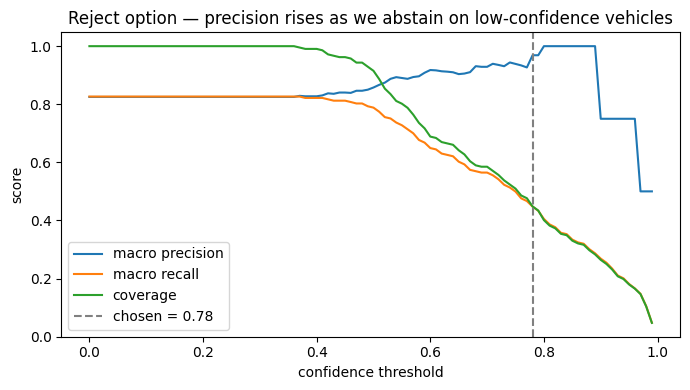

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

for column, label in [
    ("macro_precision", "macro precision"),
    ("macro_recall", "macro recall"),
    ("coverage", "coverage"),
]:
    sns.lineplot(
        data=sweep_vehicle_df,
        x="threshold",
        y=column,
        ax=ax,
        label=label,
    )

ax.axvline(
    chosen_threshold_v,
    linestyle="--",
    color="gray",
    label=f"chosen = {chosen_threshold_v:.2f}",
)
ax.set_xlabel("confidence threshold")
ax.set_ylabel("score")
ax.set_title("Reject option — precision rises as we abstain on low-confidence vehicles")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Pattern 3 — Top-K (Precision@K)

**Application:** credit-risk review queues, loan underwriting, fraud investigation — you can only manually review $K$ cases.

- You do not care how many risky applicants exist in total; you only care about the $K$ highest-risk cases you actually pull for review.
- **Optimize for Precision@K:** of the top $K$ flagged applicants, what fraction are truly high-risk?

**Dataset:** [German credit](https://www.openml.org/d/31) from OpenML — 20 mixed numeric/categorical features, target `good` vs `bad`. Only $\approx 30\%$ are `bad`; logistic regression reaches AUROC $\approx 0.80$, so ranking quality matters.

### Load data and build a preprocessing pipeline

In [ ]:
credit = fetch_openml("credit-g", version=1, as_frame=True)
X_credit = credit.data

# Positive class = bad credit (the risky applicant we want at the top of the queue)
y_credit = (credit.target == "bad").astype(int)

num_cols = X_credit.select_dtypes(include="number").columns
cat_cols = X_credit.select_dtypes(include=["category", "object"]).columns

preprocessor = make_column_transformer(
    (StandardScaler(), num_cols),  # scale numeric features
    (OneHotEncoder(handle_unknown="ignore"), cat_cols),  # encode categoricals
)

print(f"Samples: {X_credit.shape[0]:,}")
print(f"Bad-credit rate: {y_credit.mean():.1%}")
print(f"Numeric features: {len(num_cols)}, categorical features: {len(cat_cols)}")

X_train_cr, X_test_cr, y_train_cr, y_test_cr = train_test_split(
    X_credit,
    y_credit,
    test_size=0.25,
    random_state=42,
    stratify=y_credit,
)

Samples: 1,000
Bad-credit rate: 30.0%
Numeric features: 7, categorical features: 13


In [ ]:
log_reg_credit = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000, random_state=42),
)
rf_credit = make_pipeline(
    preprocessor,
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),
)

candidates_credit = {
    "LogisticRegression": log_reg_credit,
    "RandomForest": rf_credit,
}

summary_credit = []
for name, model in candidates_credit.items():
    model.fit(X_train_cr, y_train_cr)
    scores = model.predict_proba(X_test_cr)[:, 1]
    summary_credit.append(
        {
            "model": name,
            "AUROC": roc_auc_score(y_test_cr, scores),
            "AUPRC": average_precision_score(y_test_cr, scores),
        }
    )

summary_credit_df = pd.DataFrame(summary_credit).set_index("model")
summary_credit_df

,AUROC,AUPRC
model,,
LogisticRegression,0.804267,0.650842
RandomForest,0.800229,0.634062


In [ ]:
best_name_credit = summary_credit_df["AUPRC"].idxmax()
best_model_credit = candidates_credit[best_name_credit]
proba_best_credit = best_model_credit.predict_proba(X_test_cr)[:, 1]

print(f"Selected model: {best_name_credit}")

Selected model: LogisticRegression


### Precision and recall *before* tuning

At the default $0.5$ threshold the classifier labels the whole test set — and with only $\approx 30\%$ positives, precision is modest even when recall is moderate.

In [ ]:
y_pred_default_cr = best_model_credit.predict(X_test_cr)

print("Before tuning (default threshold = 0.5):")
print(f"  Recall:    {recall_score(y_test_cr, y_pred_default_cr):.3f}")
print(f"  Precision: {precision_score(y_test_cr, y_pred_default_cr):.3f}")

Before tuning (default threshold = 0.5):
  Recall:    0.547
  Precision: 0.641


### Precision@K

Top-K is about **ranking**, not a 0.5 threshold: rank all test applicants by predicted risk, take the top $K$, and measure what fraction are truly `bad`. scikit-learn has no built-in Precision@K, so we write a tiny helper.

In [ ]:
def precision_at_k(y_true, scores, k):
    """Fraction of positives among the top-k highest-scoring examples."""
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = min(k, len(scores))  # cannot review more cases than we have

    top_k_idx = np.argsort(scores)[::-1][:k]
    return y_true[top_k_idx].mean()


K = 25  # manual review queue has room for 25 flagged applicants
p_at_k = precision_at_k(y_test_cr, proba_best_credit, K)

print(f"Precision@{K}: {p_at_k:.1%}")
print(
    f"Interpretation: {p_at_k:.0%} of the top {K} flagged applicants truly have bad credit."
)

Precision@25: 76.0%
Interpretation: 76% of the top 25 flagged applicants truly have bad credit.


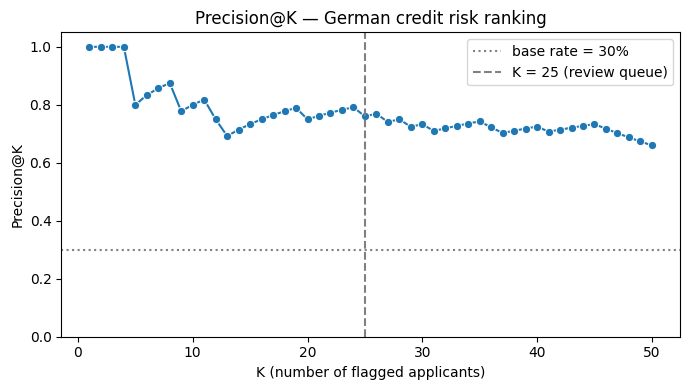

In [ ]:
k_values = range(1, min(51, len(y_test_cr) + 1))
precision_by_k = [precision_at_k(y_test_cr, proba_best_credit, k) for k in k_values]

fig, ax = plt.subplots(figsize=(7, 4))

sns.lineplot(
    x=list(k_values),
    y=precision_by_k,
    marker="o",
    ax=ax,
)
ax.axhline(
    y_test_cr.mean(),
    linestyle=":",
    color="gray",
    label=f"base rate = {y_test_cr.mean():.0%}",
)
ax.axvline(
    K,
    linestyle="--",
    color="gray",
    label=f"K = {K} (review queue)",
)
ax.set_xlabel("K (number of flagged applicants)")
ax.set_ylabel("Precision@K")
ax.set_title("Precision@K — German credit risk ranking")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

### Why Precision@K is different from recall

- **Recall** asks: "of all truly risky applicants, how many did we flag?" — it cares about the full population.
- **Precision@K** asks: "of the $K$ cases we actually pull for review, how many are truly risky?" — it only cares about the limited queue.

A model can have modest recall at $0.5$ but much higher Precision@K if it ranks the risky applicants near the top.

In [ ]:
print("At the default 0.5 threshold:")
print(f"  Recall:         {recall_score(y_test_cr, y_pred_default_cr):.1%}")
print(f"  Precision@{K}: {precision_at_k(y_test_cr, proba_best_credit, K):.1%}")
print(f"  Base rate:      {y_test_cr.mean():.1%} (random ranking would give Precision@K ≈ base rate)")

At the default 0.5 threshold:
  Recall:         54.7%
  Precision@25: 76.0%
  Base rate:      30.0% (random ranking would give Precision@K ≈ base rate)


## Recap

| Application | Dataset | Constraint | Strategy |
|---|---|---|---|
| Vehicle recognition | Vehicle silhouettes | False positives are unacceptable | Fix precision high, then recover recall (abstain when unsure) |
| Credit review queue | German credit | Only $K$ slots for manual review | Optimize Precision@K |

**The two-step process:**

1. Use **summary metrics** (AUROC, AUPRC) to compare and select the best classifier — threshold-free.
2. Tune the **operating point** to optimize the **point metric** that matches your application's error costs:
   - binary → [`TunedThresholdClassifierCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html) (or [`FixedThresholdClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.FixedThresholdClassifier.html) to deploy a hand-picked threshold);

Robustness to class imbalance increases left to right: $\text{Accuracy} < \text{AUROC} < \text{AUPRC}$. When classes are imbalanced, prefer AUPRC for model selection.
   - multiclass → a confidence (reject-option) threshold;
   - ranking → Top-K.